# Intelligent Payment Fraud Detection System

A simple end-to-end fraud detection project using the PaySim dataset.

The flow is basically:

**load data → check/clean → EDA → choose features → split → preprocess → train models → compare → tune threshold → final test → explain → save model**

> This is an educational project using synthetic data. It is not connected to any real payment network.

## 1. Load the dataset

First I want to see what is actually in the file before doing anything else.

In [1]:
from pathlib import Path  # file path
import warnings  # warnings ko control karne ke liye
warnings.filterwarnings("ignore")  # output thoda clean rahe

import numpy as np  # numerical stuff
import pandas as pd  # dataframe / csv
import matplotlib.pyplot as plt  # plots
import seaborn as sns  # better plots

RANDOM_STATE=42  # same result every time
DATA_PATH=Path("../data/PS_20174392719_1491204439457_log.csv")  # dataset path

print(DATA_PATH)  # just check path

..\data\PS_20174392719_1491204439457_log.csv


In [2]:
if not DATA_PATH.exists():  # file hai ya nahi check
    raise FileNotFoundError("PaySim CSV not found in ../data/")  # stop if path is wrong

df=pd.read_csv(DATA_PATH)  # load csv
print("shape:",df.shape)  # rows, cols
display(df.head())  # first few rows

shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 2. First data check

Abhi kuch assume nahi karna. Pehle columns, datatypes, missing values, duplicates aur basic stats dekh leta hu.

In [3]:
print(df.columns.tolist())  # all columns
print("\nDtypes")  # datatype check
display(df.dtypes.to_frame("dtype"))  # show dtypes

print("\nMissing values")  # null check
display(df.isnull().sum().to_frame("missing"))  # null count

print("\nDuplicate rows:",df.duplicated().sum())  # exact duplicate check
print("\nStats")  # basic numbers
display(df.describe(include="all").T)  # summary

['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Dtypes


,dtype
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64



Missing values


,missing
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0



Duplicate rows: 0

Stats


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,6362620.0,NaN,NaN,NaN,243.397246,142.331971,1.0,156.0,239.0,335.0,743.0
type,6362620,5,CASH_OUT,2237500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,6362620.0,NaN,NaN,NaN,179861.903549,603858.231463,0.0,13389.57,74871.94,208721.4775,92445516.64
nameOrig,6362620,6353307,C1902386530,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceOrg,6362620.0,NaN,NaN,NaN,833883.104074,2888242.673038,0.0,0.0,14208.0,107315.175,59585040.37
newbalanceOrig,6362620.0,NaN,NaN,NaN,855113.668579,2924048.502954,0.0,0.0,0.0,144258.41,49585040.37
nameDest,6362620,2722362,C1286084959,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceDest,6362620.0,NaN,NaN,NaN,1100701.66652,3399180.112994,0.0,0.0,132705.665,943036.7075,356015889.35
newbalanceDest,6362620.0,NaN,NaN,NaN,1224996.398202,3674128.94212,0.0,0.0,214661.44,1111909.25,356179278.92
isFraud,6362620.0,NaN,NaN,NaN,0.001291,0.035905,0.0,0.0,0.0,0.0,1.0


In [4]:
print("fraud values:",df["isFraud"].unique())  # target check
print("types:",df["type"].unique())  # categories check
print("negative amount:",(df["amount"]<0).sum())  # should normally be 0
print("zero amount:",(df["amount"]==0).sum())  # worth checking

fraud values: [0 1]
types: ['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']
negative amount: 0
zero amount: 16


## 3. Clean the data

Most of the PaySim file is already clean. So instead of doing random preprocessing, I only fix things that are actually a problem.

In [5]:
required_cols=["step","type","amount","isFraud"]  # columns we definitely need

before=len(df)  # rows before cleaning
df=df.dropna(subset=required_cols).copy()  # jo important data missing hai hata do
df=df.drop_duplicates().copy()  # remove exact duplicate rows

df["type"]=df["type"].astype(str).str.strip()  # clean extra spaces in category

df=df[df["amount"]>=0].copy()  # negative payment amount makes no sense here
df["isFraud"]=df["isFraud"].astype(int)  # target should be 0/1

after=len(df)  # rows after cleaning
print("rows removed:",before-after)  # see whether cleaning changed anything
print("missing left:",df[required_cols].isnull().sum().sum())  # final null check
print("duplicates left:",df.duplicated().sum())  # final duplicate check

rows removed: 0
missing left: 0
duplicates left: 0


If `rows removed` is 0, that is fine. It just means the original file did not need those fixes. Cleaning is being driven by the data instead of forcing changes just to call it "cleaning".

## 4. EDA

Now I know the file is usable, so I can actually look at fraud behaviour.

Fraud rate: 0.1291%


,transactions
isFraud,
Legitimate,6354407
Fraud,8213


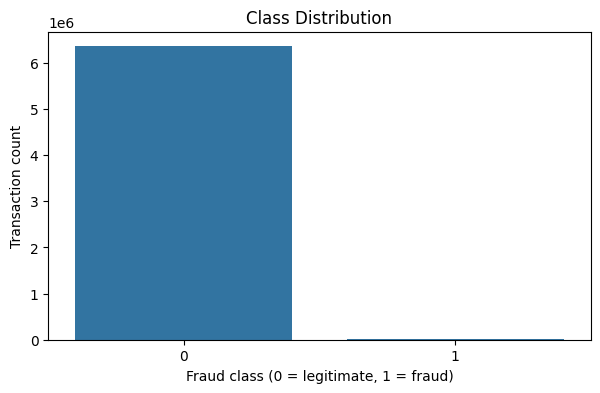

In [6]:
target_counts=df["isFraud"].value_counts().sort_index()  # class counts
fraud_rate=df["isFraud"].mean()  # fraud percentage because target is 0/1
print(f"Fraud rate: {fraud_rate:.4%}")  # class imbalance

display(target_counts.rename(index={0:"Legitimate",1:"Fraud"}).to_frame("transactions"))  # readable table

plt.figure(figsize=(7,4))  # plot size
sns.countplot(data=df,x="isFraud")  # class distribution
plt.title("Class Distribution")  # title
plt.xlabel("Fraud class (0 = legitimate, 1 = fraud)")  # x label
plt.ylabel("Transaction count")  # y label
plt.show()  # show plot

Fraud is a very small minority class, so accuracy by itself is not enough. A model could predict almost everything as legitimate and still get high accuracy.

,transactions,fraud_count,fraud_rate
type,,,
CASH_OUT,2237500,4116,0.001840
TRANSFER,532909,4097,0.007688
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


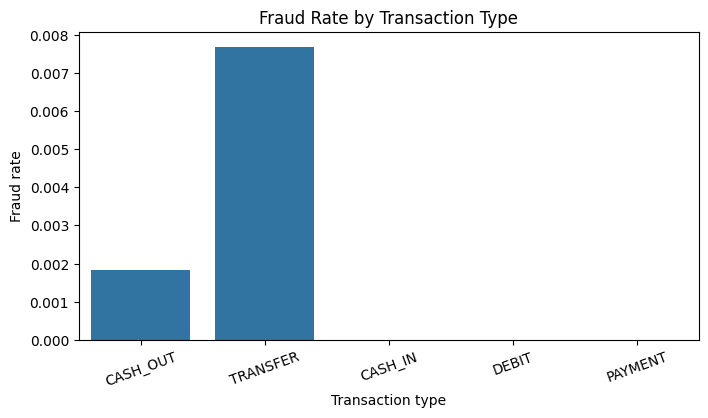

In [7]:
type_summary=(df.groupby("type").agg(  # group by transaction type
    transactions=("isFraud","size"),  # total transactions
    fraud_count=("isFraud","sum"),  # number of frauds
    fraud_rate=("isFraud","mean")  # fraud rate
).sort_values("fraud_count",ascending=False))  # show highest fraud counts first

display(type_summary)  # view table

plt.figure(figsize=(8,4))  # plot size
sns.barplot(data=type_summary.reset_index(),x="type",y="fraud_rate")  # fraud rate by type
plt.title("Fraud Rate by Transaction Type")  # title
plt.xlabel("Transaction type")  # x label
plt.ylabel("Fraud rate")  # y label
plt.xticks(rotation=20)  # labels readable
plt.show()  # show plot

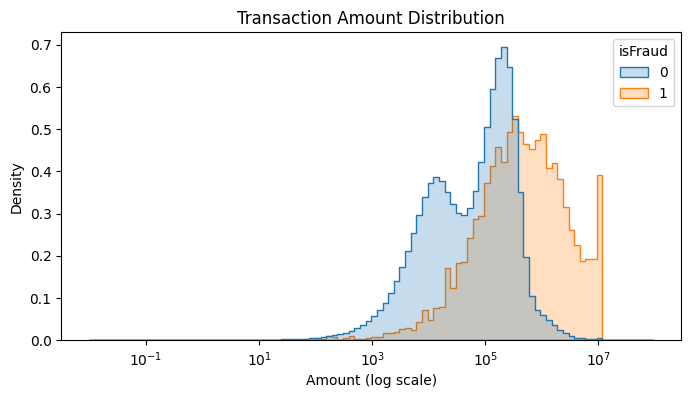

In [8]:
fig,ax=plt.subplots(figsize=(8,4))  # create plot
sns.histplot(data=df,x="amount",hue="isFraud",bins=100,log_scale=True,  # amount is very skewed
             element="step",stat="density",common_norm=False,ax=ax)  # compare both classes
ax.set_title("Transaction Amount Distribution")  # title
ax.set_xlabel("Amount (log scale)")  # x label
ax.set_ylabel("Density")  # y label
plt.show()  # show plot

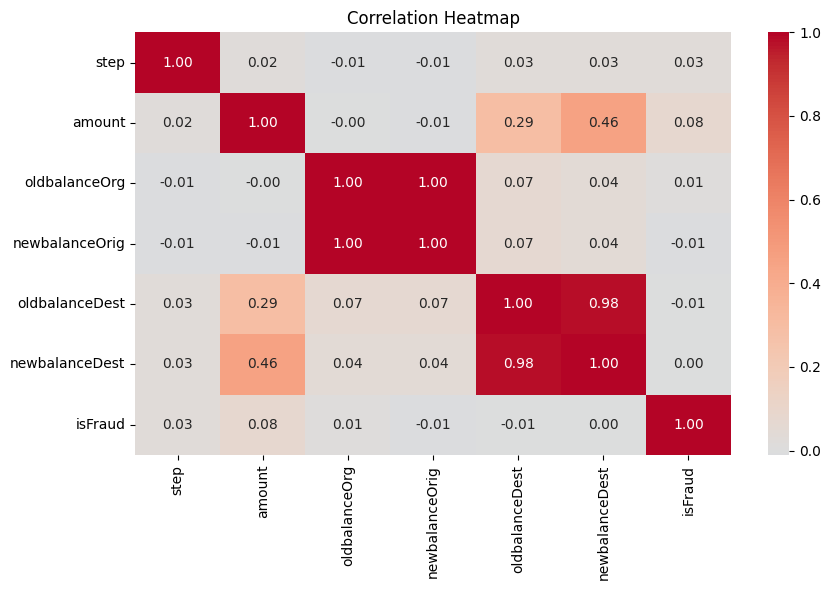

In [9]:
numeric_eda=["step","amount","oldbalanceOrg","newbalanceOrig",  # columns I want to inspect
             "oldbalanceDest","newbalanceDest","isFraud"]
corr=df[numeric_eda].corr(numeric_only=True)  # correlation check

plt.figure(figsize=(9,6))  # heatmap size
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",center=0)  # show correlations
plt.title("Correlation Heatmap")  # title
plt.tight_layout()  # fit labels
plt.show()  # show plot

## 5. Decide the model features

The model is intentionally kept small and easy to use from the Flask form.

I will use:

- `step`
- `type`
- `amount`

Two extra signals are derived *inside the pipeline* from these same three inputs (so the Flask form does not change): the **hour of day** (`step % 24`, since `step` is hours since the start) and **log(amount)**.

I am not using `nameOrig`/`nameDest` because they are identifiers, `isFlaggedFraud` because it is an existing rule-based flag, and the balance columns because the PaySim documentation has a specific caveat around using them for fraud detection.

In [10]:
MODEL_NUMERIC=["step","amount"]  # numerical model inputs
MODEL_CATEGORICAL=["type"]  # categorical input

def make_features(data):  # same feature selection can be reused later
    return data[["step","type","amount"]].copy()  # keep only model columns

X_all=make_features(df)  # input features
y_all=df["isFraud"].astype(int)  # target

print("features:",X_all.columns.tolist())  # quick check

features: ['step', 'type', 'amount']


## 6. Split the data

Test data should sit aside before fitting anything. Then I use a smaller majority-class training pool because the full dataset is huge and fraud is rare. Since legitimate rows are down-sampled, each kept legitimate row gets a weight in validation so precision / threshold reflect the real fraud rate.

In [11]:
from sklearn.model_selection import train_test_split  # split data

X_train_full,X_test,y_train_full,y_test=train_test_split(  # keep final test untouched
    X_all,y_all,test_size=0.20,random_state=RANDOM_STATE,stratify=y_all
)

MAX_LEGITIMATE_TRAIN=300_000  # cap the huge majority class for practical training
fraud_train=X_train_full[y_train_full==1]  # keep all fraud examples
legit_train=X_train_full[y_train_full==0]  # majority class
legit_total=len(legit_train)  # legit rows before sampling

if len(legit_train)>MAX_LEGITIMATE_TRAIN:  # data bahut hai to thoda sample karte hain
    rng=np.random.RandomState(RANDOM_STATE)  # repeatable sampling
    keep_idx=rng.choice(len(legit_train),size=MAX_LEGITIMATE_TRAIN,replace=False)  # random legit rows
    legit_train=legit_train.iloc[keep_idx]  # smaller legit set

legit_weight=legit_total/len(legit_train)  # one kept legit row stands for this many real legit rows

X_model=pd.concat([legit_train,fraud_train],axis=0)  # combine both classes
y_model=pd.concat([  # create matching target values
    pd.Series(0,index=legit_train.index),  # legit = 0
    pd.Series(1,index=fraud_train.index)  # fraud = 1
]).loc[X_model.index]  # keep same row order

shuffle_idx=np.random.RandomState(RANDOM_STATE).permutation(len(X_model))  # shuffle rows
X_model=X_model.iloc[shuffle_idx].reset_index(drop=True)  # shuffled X
y_model=y_model.iloc[shuffle_idx].reset_index(drop=True)  # shuffled y

X_fit,X_valid,y_fit,y_valid=train_test_split(  # fit vs validation
    X_model,y_model,test_size=0.20,random_state=RANDOM_STATE,stratify=y_model
)

valid_weight=np.where(y_valid==1,1.0,legit_weight)  # weights that put validation back at the real fraud rate

print("full train:",X_train_full.shape)  # original train part
print("model pool:",X_model.shape)  # actual pool used for model selection
print("fit:",X_fit.shape)  # model fit data
print("valid:",X_valid.shape)  # threshold/model selection data
print("test:",X_test.shape)  # untouched final test

full train: (5090096, 3)
model pool: (306570, 3)
fit: (245256, 3)
valid: (61314, 3)
test: (1272524, 3)


## 7. Preprocessing

Numerical and categorical columns need different treatment. I keep preprocessing inside each pipeline so the same steps are used again when Flask makes a prediction.

In [12]:
from sklearn.compose import ColumnTransformer  # different preprocessing per column type
from sklearn.impute import SimpleImputer  # fill missing values if they appear
from sklearn.pipeline import Pipeline  # chain preprocessing + model
from sklearn.preprocessing import OneHotEncoder,StandardScaler,FunctionTransformer  # encoding and scaling
from operator import methodcaller  # picklable way to do step%24 (a lambda would break joblib.dump)

numeric_preprocessor=Pipeline([  # numeric steps
    ("imputer",SimpleImputer(strategy="median")),  # fill missing numbers
    ("scaler",StandardScaler())  # scale numeric values
])

categorical_preprocessor=Pipeline([  # category steps
    ("imputer",SimpleImputer(strategy="most_frequent")),  # fill missing category
    ("onehot",OneHotEncoder(handle_unknown="ignore"))  # convert category to columns
])

hour_transformer=Pipeline([  # hour of day from step (step = hours since start)
    ("hour",FunctionTransformer(methodcaller("mod",24))),  # step % 24
    ("imputer",SimpleImputer(strategy="median")),  # fill missing if it appears
    ("onehot",OneHotEncoder(handle_unknown="ignore"))  # 24 hour columns
])

log_amount_transformer=Pipeline([  # amount is very skewed, so also give the model log(amount)
    ("log",FunctionTransformer(np.log1p)),  # log(1+amount)
    ("imputer",SimpleImputer(strategy="median")),  # fill missing if it appears
    ("scaler",StandardScaler())  # scale
])

preprocessor=ColumnTransformer([  # combine everything
    ("num",numeric_preprocessor,MODEL_NUMERIC),  # apply numeric pipeline
    ("cat",categorical_preprocessor,MODEL_CATEGORICAL),  # apply category pipeline
    ("hour",hour_transformer,["step"]),  # hour of day
    ("log_amount",log_amount_transformer,["amount"])  # log amount
])

## 8. Train a few models

I am comparing three models instead of assuming one will work best.

In [13]:
from sklearn.linear_model import LogisticRegression  # simple baseline
from sklearn.ensemble import RandomForestClassifier,HistGradientBoostingClassifier  # tree models
from sklearn.preprocessing import OrdinalEncoder  # compact category encoding for HGB

logistic_pipeline=Pipeline([  # logistic regression pipeline
    ("preprocess",preprocessor),  # preprocessing first
    ("model",LogisticRegression(class_weight="balanced",max_iter=1000,random_state=RANDOM_STATE))  # train classifier
])

rf_pipeline=Pipeline([  # random forest pipeline
    ("preprocess",preprocessor),  # preprocessing
    ("model",RandomForestClassifier(n_estimators=200,class_weight="balanced_subsample",  # 200 trees
                                     random_state=RANDOM_STATE,n_jobs=-1,min_samples_leaf=2))  # train RF
])

hgb_preprocessor=ColumnTransformer([  # HGB needs a dense numeric representation
    ("num",Pipeline([("imputer",SimpleImputer(strategy="median"))]),MODEL_NUMERIC),  # numeric columns
    ("cat",Pipeline([  # category columns
        ("imputer",SimpleImputer(strategy="most_frequent")),  # fill missing category
        ("ordinal",OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1))  # compact encoding
    ]),MODEL_CATEGORICAL),
    ("hour",Pipeline([  # hour of day from step
        ("hour",FunctionTransformer(methodcaller("mod",24))),  # step % 24
        ("imputer",SimpleImputer(strategy="median"))  # fill missing if any
    ]),["step"])
])

hgb_pipeline=Pipeline([  # gradient boosting pipeline
    ("preprocess",hgb_preprocessor),  # HGB preprocessing
    ("model",HistGradientBoostingClassifier(max_iter=150,learning_rate=0.08,  # boosting settings
                                             max_leaf_nodes=31,random_state=RANDOM_STATE))  # train HGB
])

models={  # keep models together
    "Logistic Regression":logistic_pipeline,
    "Random Forest":rf_pipeline,
    "HistGradientBoosting":hgb_pipeline
}

In [14]:
for name,model in models.items():  # train each model
    print("training:",name)  # progress
    model.fit(X_fit,y_fit)  # fit on training data

print("done")  # all models trained

training: Logistic Regression
training: Random Forest
training: HistGradientBoosting
done


## 9. Compare the models

The validation set is used here (re-weighted to the real fraud rate, see section 6). Models are ranked by PR-AUC because it does not depend on the threshold. The final test set is still untouched.

In [15]:
from sklearn.metrics import (precision_score,recall_score,f1_score,roc_auc_score,  # basic metrics
                             average_precision_score,confusion_matrix,classification_report)  # more metrics

validation_results=[]  # store metric rows
validation_probabilities={}  # keep probabilities for threshold tuning

for name,model in models.items():  # evaluate each model
    prob=model.predict_proba(X_valid)[:,1]  # fraud probability
    pred=(prob>=0.50).astype(int)  # pehle 0.5 pe check kar lete hain
    validation_probabilities[name]=prob  # save probs

    validation_results.append({  # save metrics
        "Model":name,
        "Precision":precision_score(y_valid,pred,zero_division=0,sample_weight=valid_weight),
        "Recall":recall_score(y_valid,pred,zero_division=0,sample_weight=valid_weight),
        "F1 Score":f1_score(y_valid,pred,zero_division=0,sample_weight=valid_weight),
        "ROC-AUC":roc_auc_score(y_valid,prob,sample_weight=valid_weight),
        "PR-AUC":average_precision_score(y_valid,prob,sample_weight=valid_weight)
    })

validation_results_df=pd.DataFrame(validation_results).sort_values("PR-AUC",ascending=False)  # best PR-AUC on top
display(validation_results_df.style.format({c:"{:.4f}" for c in validation_results_df.columns if c!="Model"}))  # show table

,Model,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
2,HistGradientBoosting,0.3466,0.6088,0.4417,0.9711,0.5586
1,Random Forest,0.1052,0.6629,0.1816,0.9642,0.4297
0,Logistic Regression,0.0092,0.8737,0.0182,0.9502,0.0674


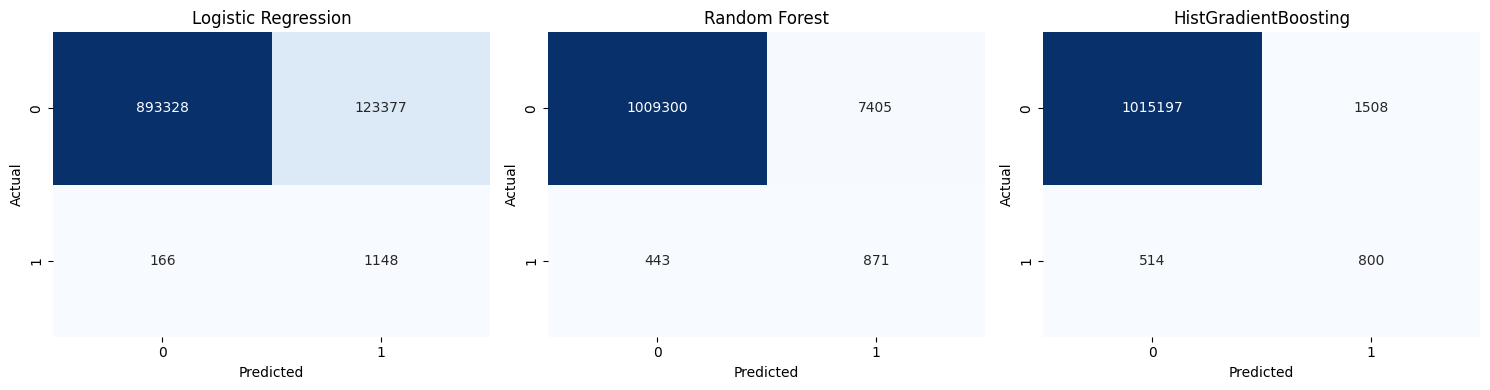

In [16]:
fig,axes=plt.subplots(1,3,figsize=(15,4))  # 3 model confusion matrices

for ax,(name,prob) in zip(axes,validation_probabilities.items()):  # loop through models
    pred=(prob>=0.50).astype(int)  # 0.5 predictions
    cm=confusion_matrix(y_valid,pred,sample_weight=valid_weight)  # actual vs predicted
    sns.heatmap(cm,annot=True,fmt=".0f",cmap="Blues",ax=ax,cbar=False)  # show matrix
    ax.set_title(name)  # model name
    ax.set_xlabel("Predicted")  # x label
    ax.set_ylabel("Actual")  # y label

plt.tight_layout()  # fit everything
plt.show()  # show all 3

## 10. Tune the fraud threshold

0.50 is just a starting point. I check a range of thresholds on the (re-weighted) validation set and keep the one with the best F1-score for the selected model.

,threshold,precision,recall,f1
77,0.82,0.657295,0.494673,0.564505
78,0.83,0.677582,0.487823,0.567254
79,0.84,0.698460,0.477930,0.567524
80,0.85,0.709239,0.471842,0.566682
81,0.86,0.735959,0.467275,0.571618
82,0.87,0.763875,0.458904,0.573359
83,0.88,0.794883,0.449772,0.574482
84,0.89,0.872156,0.439878,0.584806
85,0.90,0.892715,0.429224,0.579716
86,0.91,0.889569,0.415525,0.566455


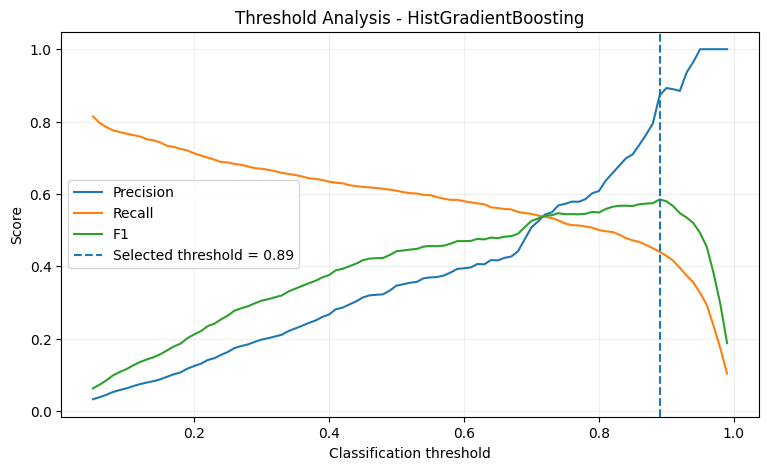

selected model: HistGradientBoosting
best threshold: 0.8900000000000002


In [17]:
selected_by_default=validation_results_df.iloc[0]["Model"]  # model with highest validation PR-AUC
selected_validation_prob=validation_probabilities[selected_by_default]  # its validation probabilities

thresholds=np.arange(0.05,1.0,0.01)  # thresholds to test
threshold_rows=[]  # store results

for threshold in thresholds:  # check each threshold
    pred=(selected_validation_prob>=threshold).astype(int)  # predictions at this threshold
    threshold_rows.append({  # save metrics
        "threshold":threshold,
        "precision":precision_score(y_valid,pred,zero_division=0,sample_weight=valid_weight),
        "recall":recall_score(y_valid,pred,zero_division=0,sample_weight=valid_weight),
        "f1":f1_score(y_valid,pred,zero_division=0,sample_weight=valid_weight)
    })

threshold_df=pd.DataFrame(threshold_rows)  # results table
best_threshold=float(threshold_df.loc[threshold_df["f1"].idxmax(),"threshold"])  # best F1 threshold

display(threshold_df.loc[threshold_df["f1"].nlargest(10).index].sort_values("threshold"))  # top thresholds

plt.figure(figsize=(9,5))  # plot
plt.plot(threshold_df["threshold"],threshold_df["precision"],label="Precision")  # precision curve
plt.plot(threshold_df["threshold"],threshold_df["recall"],label="Recall")  # recall curve
plt.plot(threshold_df["threshold"],threshold_df["f1"],label="F1")  # F1 curve
plt.axvline(best_threshold,linestyle="--",label=f"Selected threshold = {best_threshold:.2f}")  # mark best
plt.xlabel("Classification threshold")  # x label
plt.ylabel("Score")  # y label
plt.title(f"Threshold Analysis - {selected_by_default}")  # title
plt.legend()  # legend
plt.grid(alpha=0.2)  # light grid
plt.show()  # show plot

print("selected model:",selected_by_default)  # selected model
print("best threshold:",best_threshold)  # selected threshold

## 11. Final test

Now I retrain the selected model on the whole modeling pool and evaluate once on the untouched test set.

In [18]:
final_pipeline=models[selected_by_default]  # selected model
final_pipeline.fit(X_model,y_model)  # ab selected model ko full model pool pe train karte hain

test_probability=final_pipeline.predict_proba(X_test)[:,1]  # fraud probability on unseen test data
test_prediction=(test_probability>=best_threshold).astype(int)  # apply validation-selected threshold

final_metrics={  # final numbers
    "Precision":precision_score(y_test,test_prediction,zero_division=0),
    "Recall":recall_score(y_test,test_prediction,zero_division=0),
    "F1 Score":f1_score(y_test,test_prediction,zero_division=0),
    "ROC-AUC":roc_auc_score(y_test,test_probability),
    "PR-AUC":average_precision_score(y_test,test_probability)
}

display(pd.DataFrame([final_metrics]).T.rename(columns={0:"Final test result"}).style.format("{:.4f}"))  # show metrics

print(classification_report(y_test,test_prediction,target_names=["Legitimate","Fraud"],zero_division=0))  # detailed report

,Final test result
Precision,0.7442
Recall,0.4090
F1 Score,0.5279
ROC-AUC,0.9736
PR-AUC,0.5009


              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00   1270881
       Fraud       0.74      0.41      0.53      1643

    accuracy                           1.00   1272524
   macro avg       0.87      0.70      0.76   1272524
weighted avg       1.00      1.00      1.00   1272524



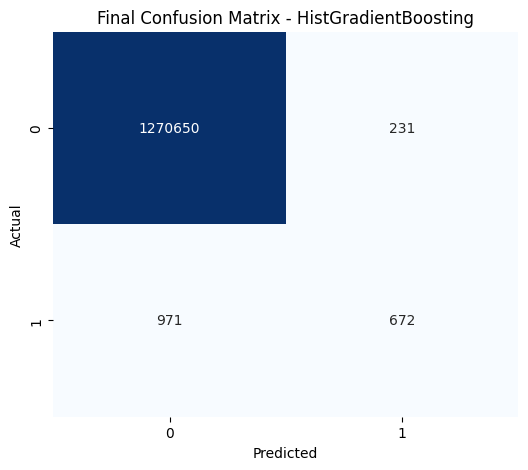

In [19]:
cm=confusion_matrix(y_test,test_prediction)  # final confusion matrix
plt.figure(figsize=(6,5))  # plot size
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False)  # show counts
plt.title(f"Final Confusion Matrix - {selected_by_default}")  # title
plt.xlabel("Predicted")  # x label
plt.ylabel("Actual")  # y label
plt.show()  # show

## 12. Feature importance

I use permutation importance on a small part of the test set. This tells me which input feature hurts the score most when shuffled.

This is only an interpretation tool; it does not mean the feature causes fraud.

,feature,importance
1,type,0.253520
0,step,0.248987
2,amount,0.243643


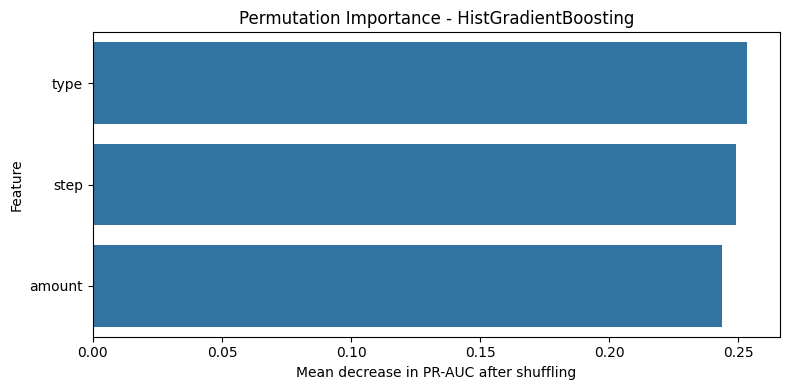

In [20]:
from sklearn.inspection import permutation_importance  # feature importance by shuffling

importance_sample=X_test.sample(n=min(5000,len(X_test)),random_state=RANDOM_STATE)  # small test sample for speed
importance_target=y_test.loc[importance_sample.index]  # matching labels

perm=permutation_importance(final_pipeline,importance_sample,importance_target,  # run importance
                            scoring="average_precision",n_repeats=3,random_state=RANDOM_STATE,n_jobs=-1)

feature_importance=pd.DataFrame({  # readable table
    "feature":importance_sample.columns,
    "importance":perm.importances_mean
}).sort_values("importance",ascending=False)  # highest first

display(feature_importance)  # show importance

plt.figure(figsize=(8,4))  # plot size
sns.barplot(data=feature_importance,x="importance",y="feature")  # bar chart
plt.title(f"Permutation Importance - {selected_by_default}")  # title
plt.xlabel("Mean decrease in PR-AUC after shuffling")  # x label
plt.ylabel("Feature")  # y label
plt.tight_layout()  # fit labels
plt.show()  # show

## 13. Save the model for Flask

The preprocessing and model go together so `app.py` can load one file and use the same transformations as training.

In [21]:
import joblib  # save model

artifact={  # everything needed later for prediction
    "pipeline":final_pipeline,  # preprocessing + model
    "threshold":best_threshold,  # fraud decision cutoff
    "risk_thresholds":{  # app-level demo bands
        "low_max":0.30,
        "medium_max":0.70
    },
    "features":list(X_model.columns),  # expected input columns
    "model_name":selected_by_default  # which model won validation
}

MODEL_PATH=Path("../models/fraud_model.pkl")  # save location
MODEL_PATH.parent.mkdir(parents=True,exist_ok=True)  # create folder if needed
joblib.dump(artifact,MODEL_PATH)  # export model

print("saved:",MODEL_PATH.resolve())  # exact file
print("model:",selected_by_default)  # saved model
print("threshold:",best_threshold)  # saved threshold

saved: C:\Users\astit\OneDrive\Desktop\Projects\ml projs\intelligent-payment-fraud-detection\models\fraud_model.pkl
model: HistGradientBoosting
threshold: 0.8900000000000002


## 14. Reload once and check it

This is just a quick sanity check that the exported file can actually be loaded and used independently.

In [22]:
loaded_artifact=joblib.load(MODEL_PATH)  # load saved artifact
loaded_pipeline=loaded_artifact["pipeline"]  # get pipeline

sample=X_test.head(5)  # 5 unseen rows
sample_prob=loaded_pipeline.predict_proba(sample)[:,1]  # probability
sample_pred=(sample_prob>=loaded_artifact["threshold"]).astype(int)  # final prediction

verification=pd.DataFrame({  # easy to read
    "fraud_probability":sample_prob,
    "prediction":sample_pred
})
display(verification)  # show result

assert len(sample_prob)==len(sample)  # one prediction per row
assert np.all((sample_prob>=0)&(sample_prob<=1))  # probability range theek hai
print("saved-model check passed")  # done

,fraud_probability,prediction
0,0.018553,0
1,0.000007,0
2,0.000303,0
3,0.003686,0
4,0.003641,0


saved-model check passed


## 15. Final notes

### What the notebook does

`raw data → checks → cleaning → EDA → feature selection → split → preprocessing → model comparison → threshold tuning → final test → feature importance → model export`

### Important points for the meeting

- Fraud is highly imbalanced here, so accuracy is not the main metric.
- The model was selected by validation PR-AUC. Validation is re-weighted so it matches the real fraud rate (legitimate rows were down-sampled for training).
- Hour of day (`step % 24`) and log(amount) are derived inside the pipeline from the same three inputs, so the saved model still takes only `step`, `type`, `amount`.
- The fraud threshold was then tuned on validation data, not on the final test data.
- The saved artifact contains preprocessing + model + threshold, so Flask does not need to rebuild the pipeline.
- PaySim is synthetic, so these results should not be treated as real payment-network performance.